# Exercício 1

Utilizando o método ingênuo gere uma amostra de tamanho $M=1000$ de uma variável geométrica com parâmetro $p$. Compara o gráfico da sua distribuição com a função do numpy. Além disso, compare o que acontece quando você varia o valor $p$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import interact
import ipywidgets as iw

tamanho_amostra = 1000 # M da questão
p_amostra = 0.5
qtde_barras = 20

#valores_p = np.linspace(0, 0.99, num = 10)
valores_p = [0.2, 0.5, 0.6]

def metodoIngenuoGeometrica(p):
  i = 1
  while np.random.uniform(0,1) > p:
    i+=1
  return i

def metodoInversaoGeometrica(p):
  u = np.random.uniform(0,1)
  x = np.floor(np.log(1 - u)/np.log(1 - p)) + 1
  return x

def preparaDicionarios(p_values, dicionario):
  for prob in p_values:
    dicionario[prob] = []
  return dicionario

big_amostra_ingenua = {}
big_amostra_inversao = {}
big_amostra_np = {}

preparaDicionarios(valores_p, big_amostra_ingenua)
preparaDicionarios(valores_p, big_amostra_inversao)
preparaDicionarios(valores_p, big_amostra_np)


for p in valores_p:
  big_amostra_np[p].append(np.random.geometric(p, size = tamanho_amostra))
  for _ in range(tamanho_amostra):
    big_amostra_ingenua[p].append(metodoIngenuoGeometrica(p))
    big_amostra_inversao[p].append(metodoInversaoGeometrica(p))

df_amostras_ingenuo = pd.DataFrame(big_amostra_ingenua)
df_amostras_inversao = pd.DataFrame(big_amostra_inversao)
df_amostras_np = pd.DataFrame(big_amostra_np)

def iwPlot(selected_p): # funçãozinha padrão pra atualizar o gráfico com o valor p selecionado
  df_filtrado_ingenuo = df_amostras_ingenuo[selected_p]
  df_filtrado_inversao = df_amostras_inversao[selected_p]
  df_filtrado_np = df_amostras_np[selected_p]

  fig, axs = plt.subplots(1, 3, sharey=True, tight_layout=True) # https://matplotlib.org/stable/gallery/statistics/hist.html
  axs[0].hist(df_filtrado_ingenuo, bins=qtde_barras)
  axs[0].set(title="Geometrica Ingenuo")

  axs[1].hist(df_filtrado_inversao, bins=qtde_barras)
  axs[1].set(title="Geometrica Inversão")

  axs[2].hist(df_filtrado_np, bins=qtde_barras)
  axs[2].set(title="Geometrica Numpy")
  plt.show()

interact(
    iwPlot,
    selected_p=iw.SelectionSlider(
        options=valores_p,
        value=valores_p[0],
        description='Valor p:',
        disabled=False,
        continuous_update=False
    )
)


interactive(children=(SelectionSlider(continuous_update=False, description='Valor p:', options=(0.2, 0.5, 0.6)…

<function __main__.iwPlot(selected_p)>

# Exercício 2

Repita o exercício anterior, porém utilizando o método de inversão. Compare o tempo gasto por esse método versus o método ingênuo do item anterior usando a função `time.time` variando o $p$, ou seja, no eixo $y$ coloque o tempo e no eixo $x$ coloque $p$.

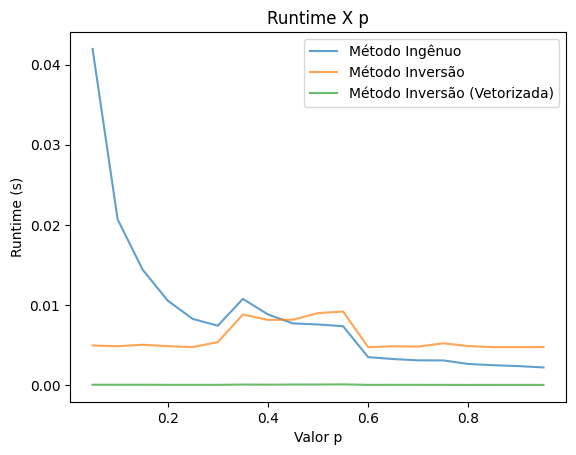

In [ ]:
import time as time
valores_p = np.linspace(0.05, 0.95, num = 19)
repeticoes = 20 # Repetições por valor p para cada método (recursivo e ingênuo)
tamanho_amostra = 1000 # Tamanho da amostra gerada para calcular o tempo
resultado = []

# Funções pra amostra que eu não fiz no exercício anterior
def amostraIngenuaGeometrica(M, p):
  amostra_ingenua = []
  for _ in range(M):
    i = 1
    while np.random.uniform(0,1) > p:
      i+=1
    amostra_ingenua.append(i)
  return amostra_ingenua

def amostraInversaoGeometricaVetorizada(M, p): # crazy efficiency
  u = np.random.uniform(0,1, size = M)
  x = np.floor(np.log(1 - u)/np.log(1 - p)) + 1
  return x

def amostraInversaoGeometrica(M, p):
  amostra_inversao = []
  for _ in range(M):
    amostra_inversao.append(metodoInversaoGeometrica(p))
  return amostra_inversao


for p in valores_p:
  runtimes_ingenuo = []
  runtimes_inversao = []
  runtimes_inversao_vetorizada = []
  for _ in range(repeticoes):
    comeco = time.time()
    amostraIngenuaGeometrica(tamanho_amostra, p)
    runtimes_ingenuo.append(time.time() - comeco)

    comeco = time.time()
    amostraInversaoGeometrica(tamanho_amostra, p)
    runtimes_inversao.append(time.time() - comeco)

    comeco = time.time()
    amostraInversaoGeometricaVetorizada(tamanho_amostra, p)
    runtimes_inversao_vetorizada.append(time.time() - comeco)

  resultado.append({
      "Valor p": p,
      "Media Ingenuo": np.mean(runtimes_ingenuo),
      "Media Inversao": np.mean(runtimes_inversao),
      "Media Inversao (Vetorizada)": np.mean(runtimes_inversao_vetorizada)
  })

df_resultado = pd.DataFrame(resultado)

fig, ax = plt.subplots()
ax.plot('Valor p', "Media Ingenuo", label="Método Ingênuo", alpha=0.7, data=df_resultado)
ax.plot('Valor p', "Media Inversao", label="Método Inversão", alpha=0.7,  data=df_resultado)
ax.plot('Valor p', "Media Inversao (Vetorizada)", label="Método Inversão (Vetorizada)", alpha=0.7,  data=df_resultado)

ax.legend()
ax.set(xlabel="Valor p", ylabel="Runtime (s)", title="Runtime X p")
plt.show()

# Exercício 3

Gere uma amostra de tamanho $M=1000$ de uma Poisson com parâmetro $\lambda$ usando o método recursivo.  

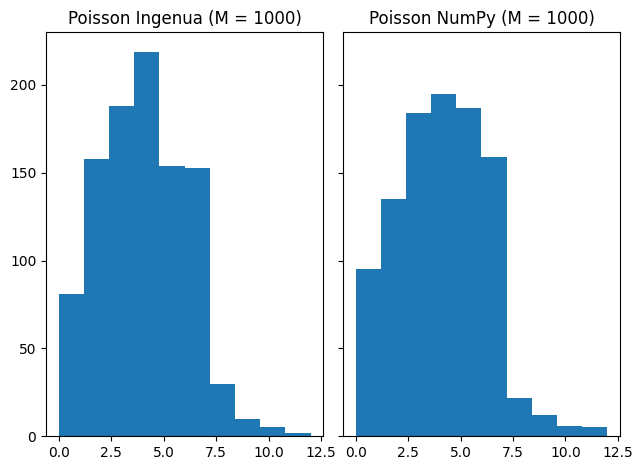

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M = 1000
lambda_amostra = 4

def poissonRecursivo(lmd):
  u = np.random.uniform(0,1)
  #print(f"U = {u}")

  i = 0
  pi = np.exp((-lmd))
  F = pi
  while u > F:
    i+=1
    pi = (lmd/i) * pi
    F = F + pi
  return i

amostra_pois = []
amostra_pois_np = np.random.poisson(lambda_amostra, size = M)
for _ in range(M):
  amostra_pois.append(poissonRecursivo(lambda_amostra))


fig, axs = plt.subplots(1, 2, sharey=True, tight_layout=True) # https://matplotlib.org/stable/gallery/statistics/hist.html
axs[0].hist(amostra_pois)
axs[0].set(title="Poisson Ingenua (M = {})".format(M))
axs[1].hist(amostra_pois_np)
axs[1].set(title="Poisson NumPy (M = {})".format(M))
plt.show()

#print(poissonRecursivo(lambda_amostra))
#print(np.random.poisson(3))